# Exploratory Data Analysis

## Adaptive Embodied AI

This notebook explores the movement dataset collected for the
Adaptive Embodied AI project.

### Research question

Can a lightweight pose-based movement recognition system benefit
from adapting to individual movement characteristics?

Before training models, we investigate whether the collected data
shows:

1. meaningful differences between movement classes,
2. individual differences in how movements are performed, and
3. consistency across sessions for the same participant.

We also compare the behaviour of 2D pose-derived features with
estimated 3D/depth features.

### Important scope

The depth values used in this project are MediaPipe pose landmark
depth estimates. They are treated as **estimated 3D information**,
not as metric 3D reconstruction.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Project paths

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "movement"

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)

Project root: c:\Users\Athanasia\Documents\09_GITHUB_PROJECTS\adaptive-embodied-ai
Data directory: c:\Users\Athanasia\Documents\09_GITHUB_PROJECTS\adaptive-embodied-ai\data\movement


In [3]:
files = sorted(DATA_DIR.glob("P*_session_*.csv"))

print(f"Found {len(files)} dataset files:")

for file in files:
    print(f"  - {file.name}")

Found 4 dataset files:
  - P01_session_01.csv
  - P01_session_02.csv
  - P02_session_01.csv
  - P02_session_02.csv


In [4]:
frames = []

for file in files:
    df = pd.read_csv(file)
    frames.append(df)

data = pd.concat(frames, ignore_index=True)

print(f"Dataset shape: {data.shape}")

Dataset shape: (12049, 14)


In [5]:
data.head()

,participant_id,session_id,trial_id,movement_label,timestamp,shoulder_width,head_offset_x,head_offset_y,torso_dx,torso_dy,movement_speed,head_offset_z,torso_dz,movement_speed_3d
0,P01,session_01,1,neutral,0.000286,0.512240,-0.003828,-0.809468,0.000000,0.000000,0.000000,-1.819797,0.000000,0.000000
1,P01,session_01,1,neutral,0.089765,0.522485,0.001988,-0.821021,0.001142,0.041825,0.467600,-1.964989,-0.080764,1.016539
2,P01,session_01,1,neutral,0.120218,0.526950,-0.002607,-0.825294,0.004594,0.006284,0.255614,-1.953916,-0.004368,0.293103
3,P01,session_01,1,neutral,0.161072,0.528400,-0.000946,-0.826692,0.001198,0.004504,0.114079,-1.970659,-0.041060,1.011501
4,P01,session_01,1,neutral,0.199235,0.528685,-0.000832,-0.819518,-0.000120,0.001390,0.036564,-2.000928,-0.021275,0.558671


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12049 entries, 0 to 12048
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   participant_id     12049 non-null  str    
 1   session_id         12049 non-null  str    
 2   trial_id           12049 non-null  int64  
 3   movement_label     12049 non-null  str    
 4   timestamp          12049 non-null  float64
 5   shoulder_width     12049 non-null  float64
 6   head_offset_x      12049 non-null  float64
 7   head_offset_y      12049 non-null  float64
 8   torso_dx           12049 non-null  float64
 9   torso_dy           12049 non-null  float64
 10  movement_speed     12049 non-null  float64
 11  head_offset_z      12049 non-null  float64
 12  torso_dz           12049 non-null  float64
 13  movement_speed_3d  12049 non-null  float64
dtypes: float64(10), int64(1), str(3)
memory usage: 1.5 MB


In [7]:
print("Participants:", data["participant_id"].nunique())
print("Sessions:", data[["participant_id", "session_id"]].drop_duplicates().shape[0])
print("Trials:", data[["participant_id", "session_id", "trial_id"]].drop_duplicates().shape[0])
print("Movements:", data["movement_label"].nunique())

Participants: 2
Sessions: 4
Trials: 100
Movements: 5


In [8]:
trial_summary = (
    data.groupby(
        [
            "participant_id",
            "session_id",
            "trial_id",
            "movement_label",
        ]
    )
    .size()
    .reset_index(name="observations")
)

trial_summary.head()

,participant_id,session_id,trial_id,movement_label,observations
0,P01,session_01,1,neutral,118
1,P01,session_01,2,neutral,121
2,P01,session_01,3,neutral,121
3,P01,session_01,4,neutral,120
4,P01,session_01,5,neutral,121


In [9]:
trial_summary["observations"].describe()

count    100.000000
mean     120.490000
std        0.771919
min      117.000000
25%      120.000000
50%      121.000000
75%      121.000000
max      121.000000
Name: observations, dtype: float64

In [10]:
trial_summary.groupby(
    ["participant_id", "session_id"]
).size()

participant_id  session_id
P01             session_01    25
                session_02    25
P02             session_01    25
                session_02    25
dtype: int64

In [11]:
movement_counts = (
    trial_summary["movement_label"]
    .value_counts()
    .sort_index()
)

movement_counts

movement_label
lean_forward    20
lean_left       20
lean_right      20
neutral         20
raise_arms      20
Name: count, dtype: int64

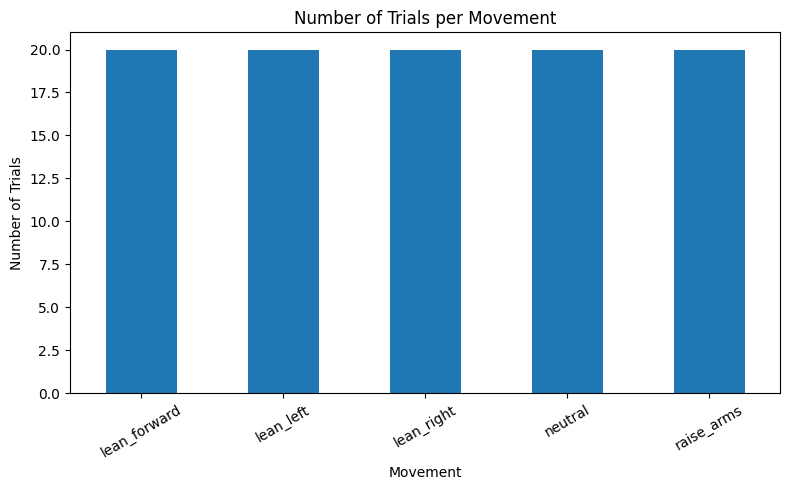

In [12]:
movement_counts.plot(
    kind="bar",
    figsize=(8, 5),
)

plt.title("Number of Trials per Movement")
plt.xlabel("Movement")
plt.ylabel("Number of Trials")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [13]:
features_2d = [
    "shoulder_width",
    "head_offset_x",
    "head_offset_y",
    "torso_dx",
    "torso_dy",
    "movement_speed",
]

features_3d = [
    "head_offset_z",
    "torso_dz",
    "movement_speed_3d",
]

print("2D features:")
for feature in features_2d:
    print(f"  - {feature}")

print("\nEstimated 3D features:")
for feature in features_3d:
    print(f"  - {feature}")

2D features:
  - shoulder_width
  - head_offset_x
  - head_offset_y
  - torso_dx
  - torso_dy
  - movement_speed

Estimated 3D features:
  - head_offset_z
  - torso_dz
  - movement_speed_3d


In [14]:
data[features_2d + features_3d].describe().T

,count,mean,std,min,25%,50%,75%,max
shoulder_width,12049.0,0.528710,0.076742,0.310685,0.494639,5.262240e-01,0.579660,0.699085
head_offset_x,12049.0,0.022251,0.127662,-0.339932,-0.014116,2.852422e-02,0.071109,0.346419
head_offset_y,12049.0,-0.792374,0.055313,-0.988570,-0.837147,-7.940897e-01,-0.757661,-0.601499
torso_dx,12049.0,0.000104,0.004970,-0.081057,-0.000968,-3.613862e-07,0.000874,0.056390
torso_dy,12049.0,-0.000347,0.006463,-0.133394,-0.001205,-8.636221e-06,0.000994,0.125286
movement_speed,12049.0,0.131681,0.210001,0.000000,0.026202,6.265194e-02,0.146790,4.138410
head_offset_z,12049.0,-1.849927,0.134953,-2.581697,-1.937890,-1.864901e+00,-1.752656,-1.449469
torso_dz,12049.0,0.000178,0.090688,-1.091230,-0.028528,-1.856505e-04,0.027297,0.801653
movement_speed_3d,12049.0,1.631177,2.237036,0.000000,0.351117,8.690020e-01,1.976559,33.875572


In [15]:
movement_means = (
    data.groupby("movement_label")[features_2d + features_3d]
    .mean()
)

movement_means

,shoulder_width,head_offset_x,head_offset_y,torso_dx,torso_dy,movement_speed,head_offset_z,torso_dz,movement_speed_3d
movement_label,,,,,,,,,
lean_forward,0.609742,0.041792,-0.830217,-0.000019,-0.000408,0.067190,-1.912116,-0.003698,1.169112
lean_left,0.511657,0.192158,-0.769668,0.002428,-0.000009,0.159940,-1.785959,0.000143,1.605304
lean_right,0.527559,-0.165264,-0.745126,-0.002020,-0.000229,0.145766,-1.720384,-0.000101,1.288068
neutral,0.574550,0.036249,-0.823230,-0.000018,0.000066,0.036748,-1.865132,0.000100,0.878890
raise_arms,0.420054,0.006415,-0.793714,0.000148,-0.001154,0.248516,-1.966109,0.004456,3.212958


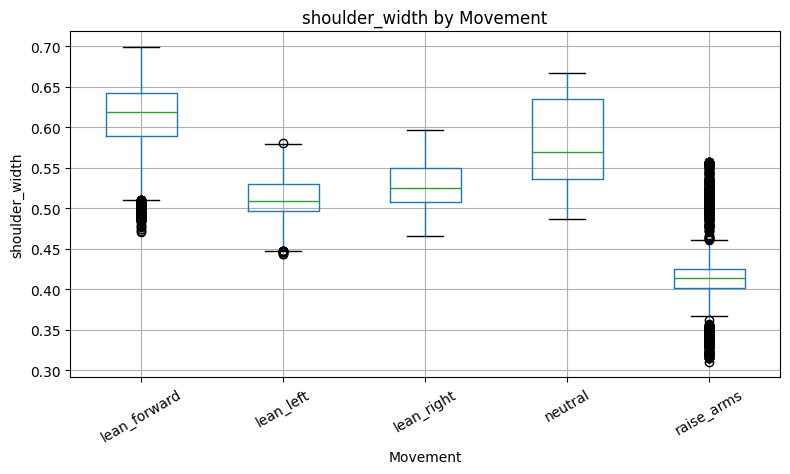

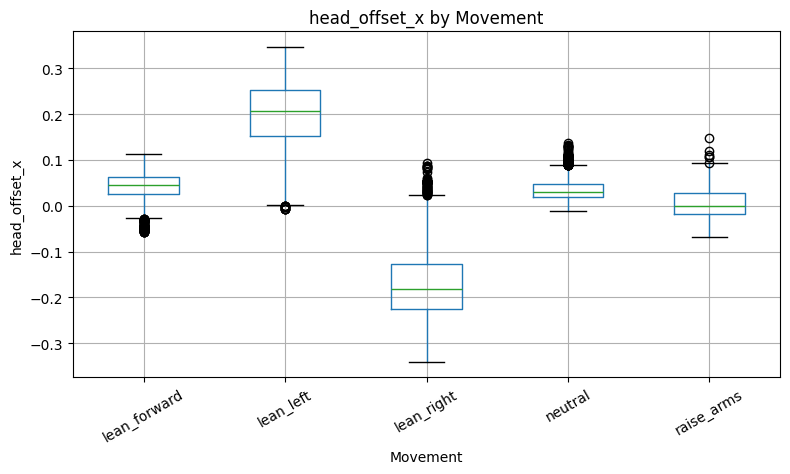

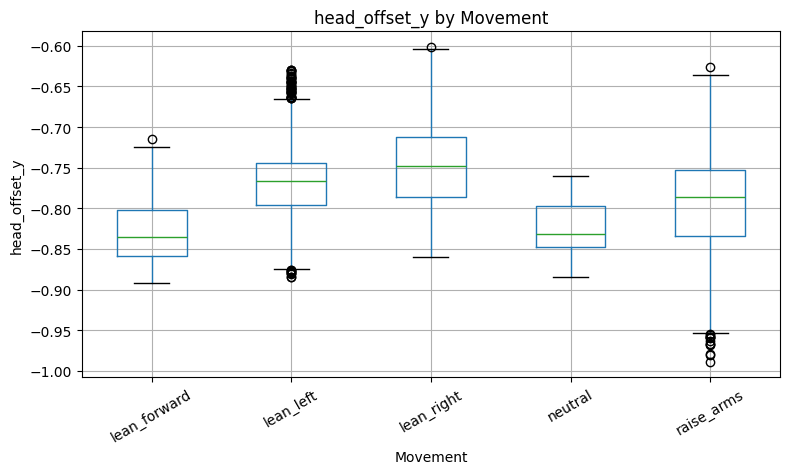

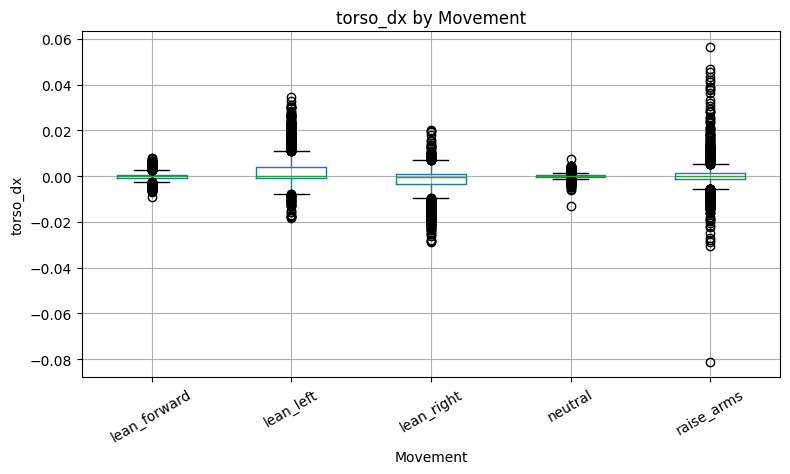

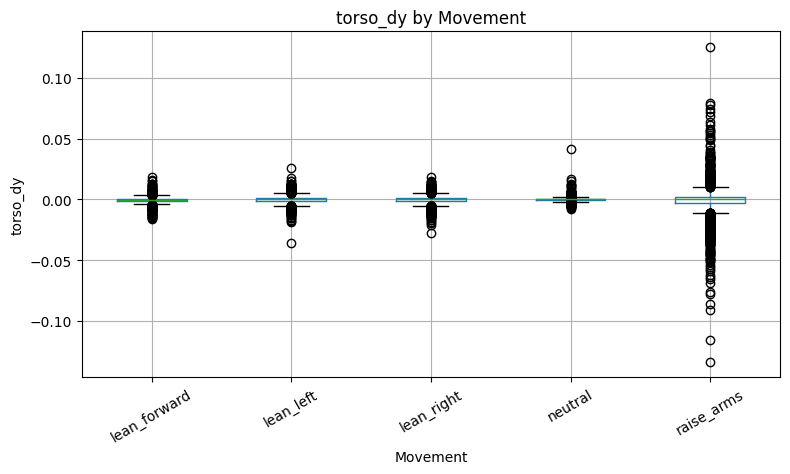

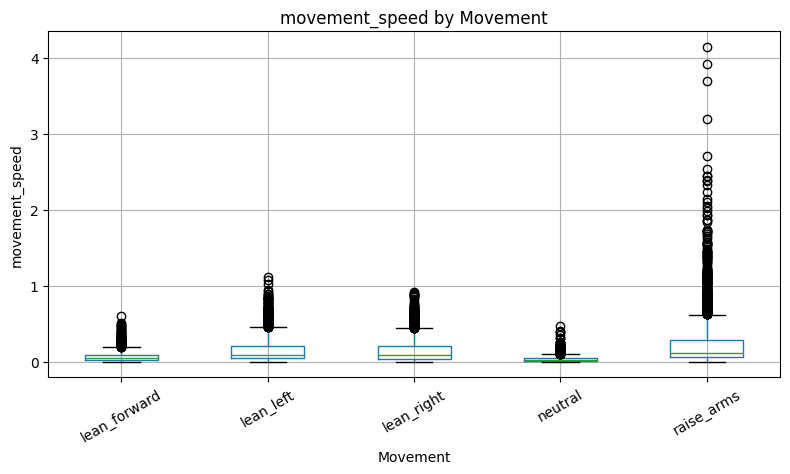

In [16]:
for feature in features_2d:
    data.boxplot(
        column=feature,
        by="movement_label",
        figsize=(8, 5),
    )

    plt.title(f"{feature} by Movement")
    plt.suptitle("")
    plt.xlabel("Movement")
    plt.ylabel(feature)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

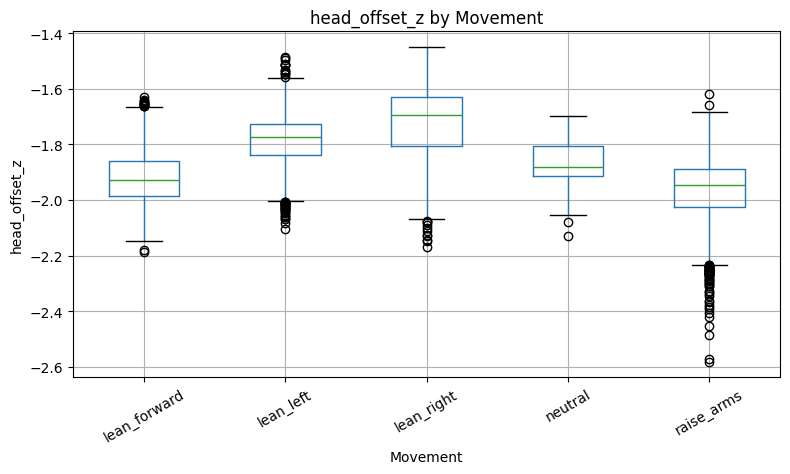

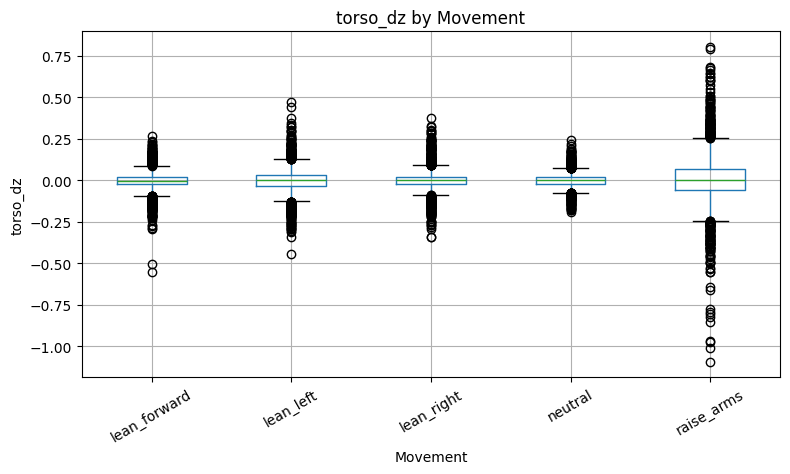

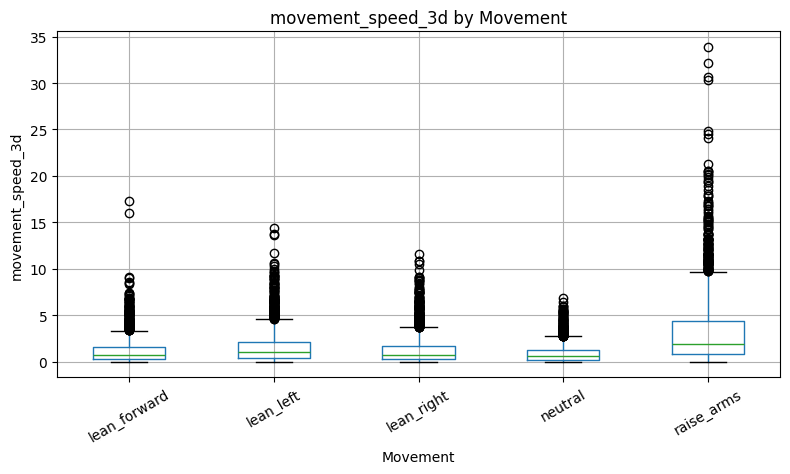

In [17]:
for feature in features_3d:
    data.boxplot(
        column=feature,
        by="movement_label",
        figsize=(8, 5),
    )

    plt.title(f"{feature} by Movement")
    plt.suptitle("")
    plt.xlabel("Movement")
    plt.ylabel(feature)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

In [18]:
participant_means = (
    data.groupby(
        ["participant_id", "movement_label"]
    )[features_2d + features_3d]
    .mean()
)

participant_means

shoulder_width  head_offset_x  head_offset_y  \
participant_id movement_label                                                 
P01            lean_forward          0.602209       0.038703      -0.845897   
               lean_left             0.503321       0.207223      -0.777466   
               lean_right            0.509075      -0.180569      -0.730195   
               neutral               0.531049       0.042242      -0.828898   
               raise_arms            0.402573       0.018375      -0.809089   
P02            lean_forward          0.617282       0.044883      -0.814523   
               lean_left             0.520027       0.177029      -0.761838   
               lean_right            0.546043      -0.149960      -0.760057   
               neutral               0.617870       0.030282      -0.817585   
               raise_arms            0.437506      -0.005525      -0.778363   

                               torso_dx  torso_dy  movement_speed  \
participant_id movement_label                                       
P01            lean_forward   -0.000021 -0.000369        0.073876   
               lean_left       0.002472 -0.000005        0.179128   
               lean_right     -0.002151 -0.000379        0.178560   
               neutral        -0.000052  0.000117        0.045350   
               raise_arms      0.000266 -0.001089        0.352268   
P02            lean_forward   -0.000016 -0.000447        0.060499   
               lean_left       0.002383 -0.000013        0.140672   
               lean_right     -0.001889 -0.000079        0.112972   
               neutral         0.000015  0.000014        0.028182   
               raise_arms      0.000031 -0.001218        0.144936   

                               head_offset_z  torso_dz  movement_speed_3d  
participant_id movement_label                                              
P01            lean_forward        -1.982112 -0.006504           1.116252  
               lean_left           -1.818181 -0.000138           2.037040  
               lean_right          -1.743330 -0.000644           1.638623  
               neutral             -1.911665  0.000458           1.098429  
               raise_arms          -2.012975  0.002508           4.017362  
P02            lean_forward        -1.842062 -0.000889           1.222015  
               lean_left           -1.753602  0.000424           1.171774  
               lean_right          -1.697438  0.000443           0.937514  
               neutral             -1.818793 -0.000257           0.660264  
               raise_arms          -1.919320  0.006400           2.409888

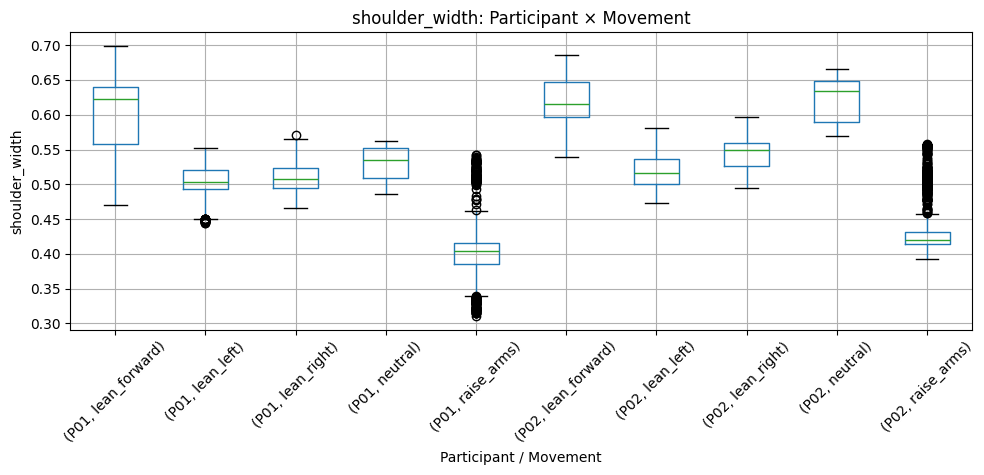

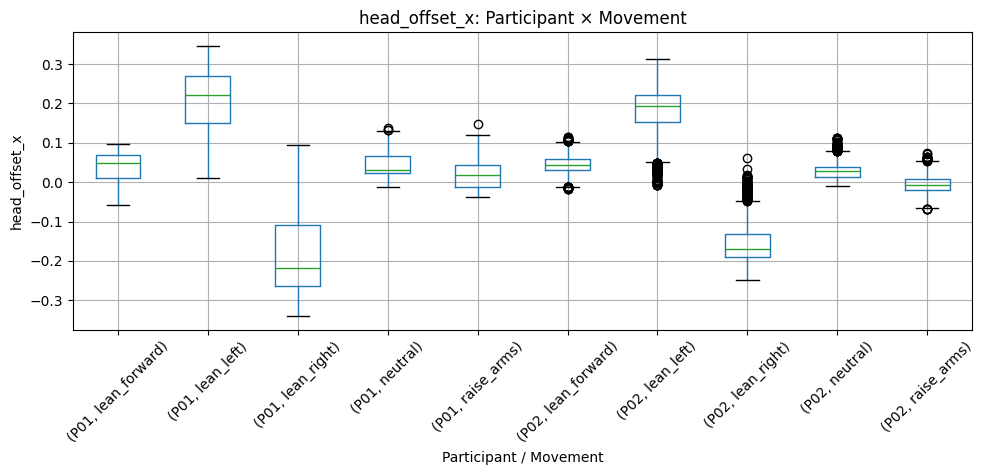

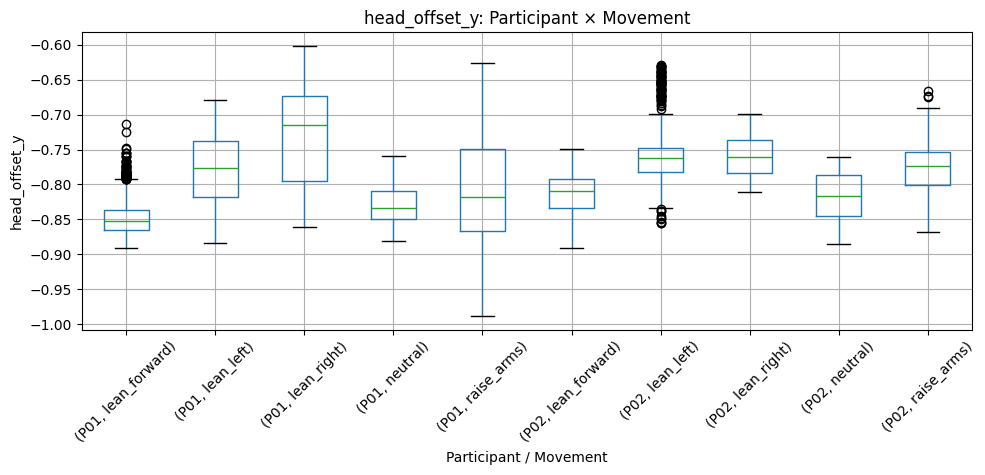

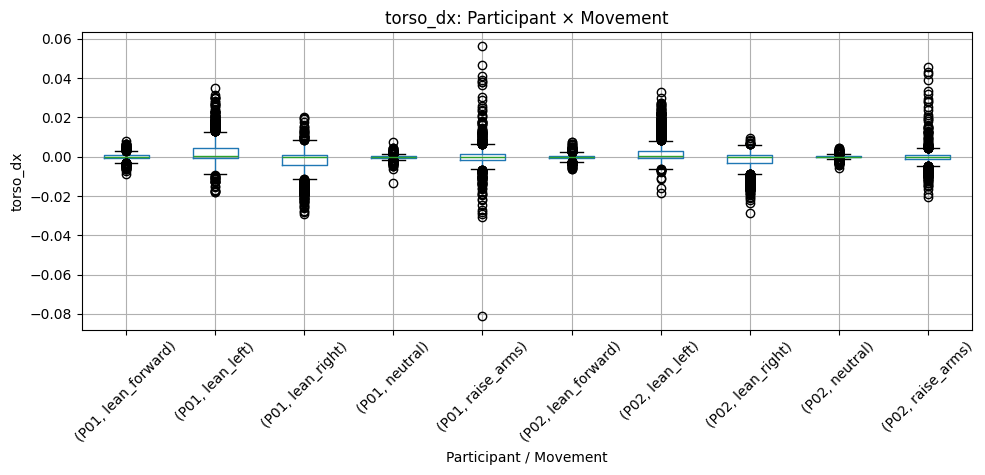

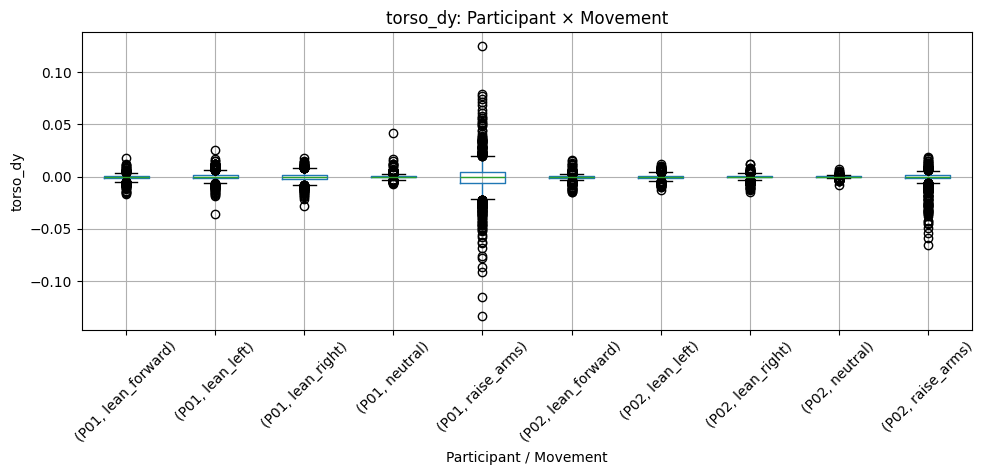

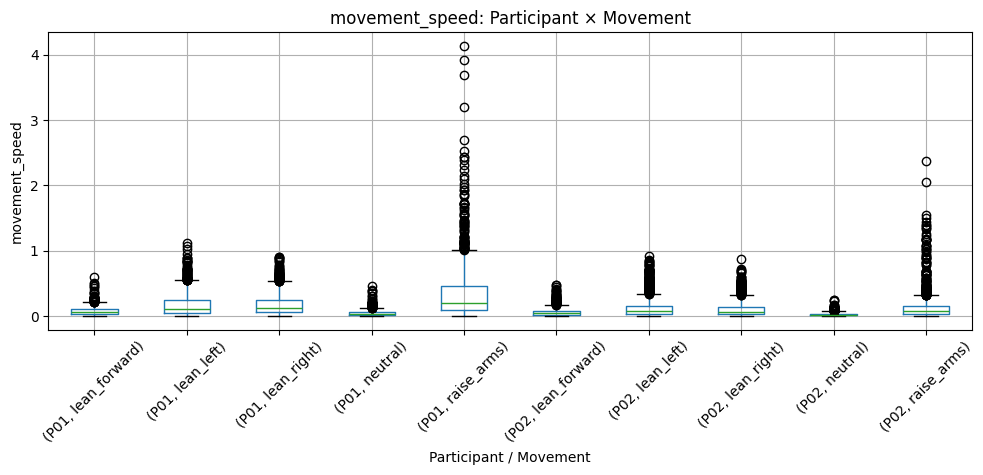

In [19]:
for feature in features_2d:
    data.boxplot(
        column=feature,
        by=["participant_id", "movement_label"],
        figsize=(10, 5),
    )

    plt.title(f"{feature}: Participant × Movement")
    plt.suptitle("")
    plt.xlabel("Participant / Movement")
    plt.ylabel(feature)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [20]:
trial_features = (
    data.groupby(
        [
            "participant_id",
            "session_id",
            "trial_id",
            "movement_label",
        ]
    )[features_2d + features_3d]
    .mean()
    .reset_index()
)

trial_features.head()

,participant_id,session_id,trial_id,movement_label,shoulder_width,head_offset_x,head_offset_y,torso_dx,torso_dy,movement_speed,head_offset_z,torso_dz,movement_speed_3d
0,P01,session_01,1,neutral,0.529612,0.019464,-0.800970,-0.000042,0.000503,0.054888,-1.887248,-0.000173,0.920003
1,P01,session_01,2,neutral,0.517385,0.025469,-0.832465,-0.000047,0.000025,0.049913,-1.904534,0.001170,0.805533
2,P01,session_01,3,neutral,0.507778,0.076977,-0.805601,0.000011,-0.000053,0.054791,-1.942788,-0.002604,1.084661
3,P01,session_01,4,neutral,0.496608,0.077936,-0.800612,-0.000030,0.000148,0.050907,-1.972181,0.001073,1.609406
4,P01,session_01,5,neutral,0.504510,0.077118,-0.807151,-0.000043,0.000269,0.066000,-1.961203,0.000298,1.223005


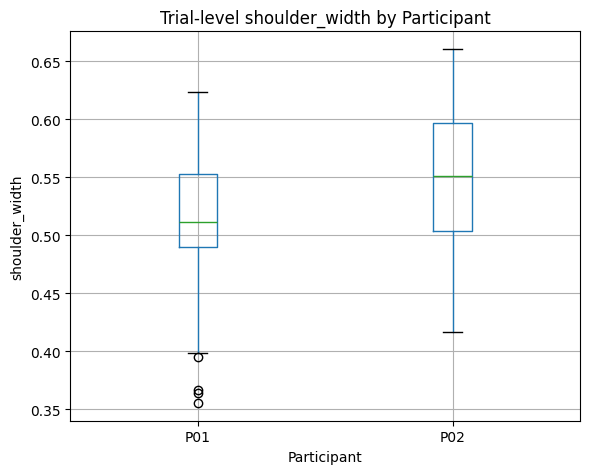

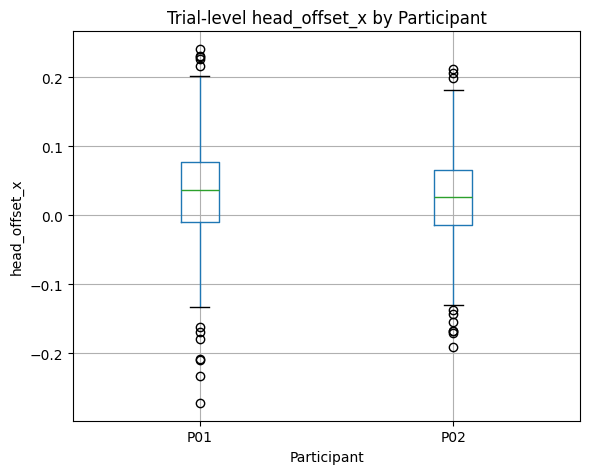

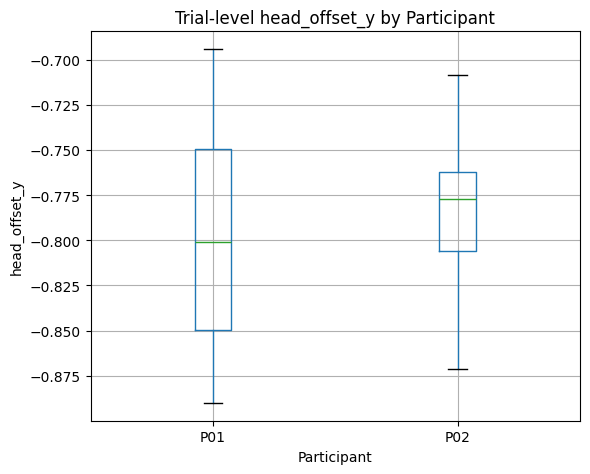

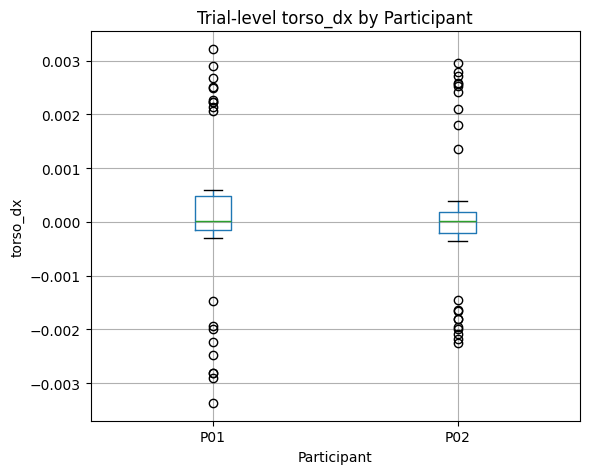

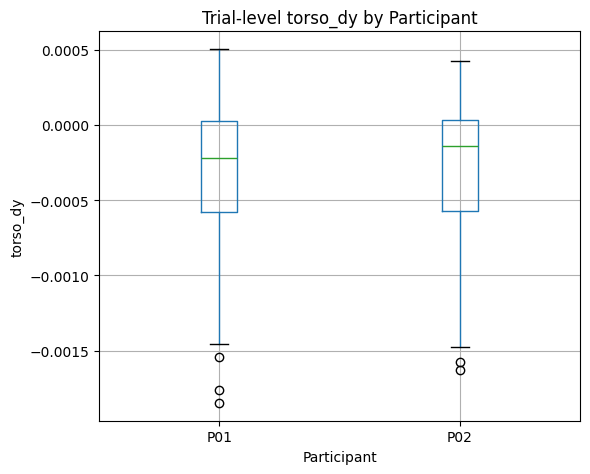

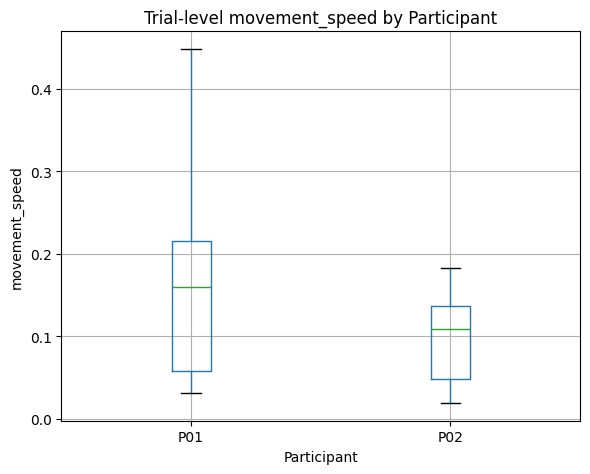

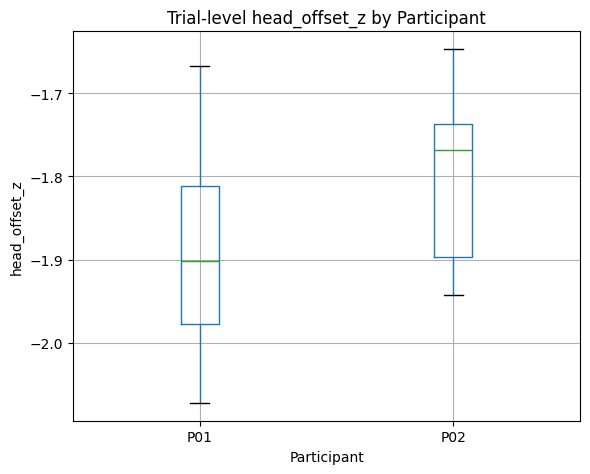

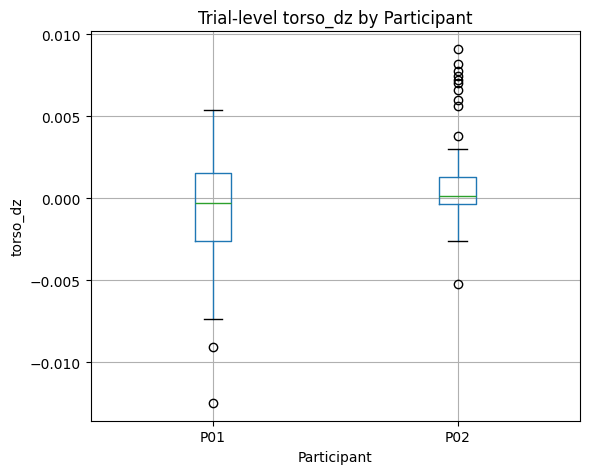

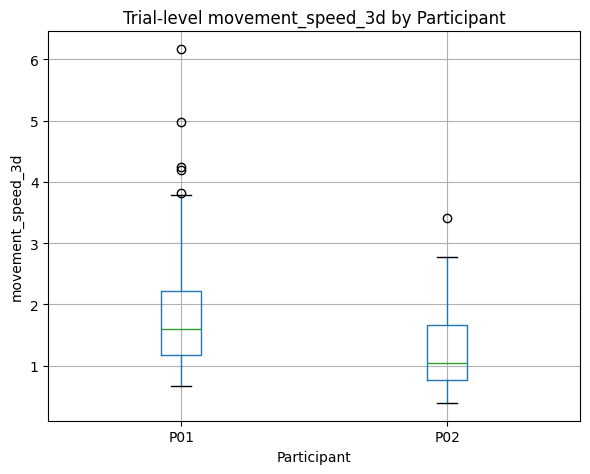

In [21]:
for feature in features_2d + features_3d:
    trial_features.boxplot(
        column=feature,
        by="participant_id",
        figsize=(6, 5),
    )

    plt.title(f"Trial-level {feature} by Participant")
    plt.suptitle("")
    plt.xlabel("Participant")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

In [22]:
session_means = (
    trial_features.groupby(
        [
            "participant_id",
            "session_id",
            "movement_label",
        ]
    )[features_2d + features_3d]
    .mean()
)

session_means

shoulder_width  head_offset_x  \
participant_id session_id movement_label                                  
P01            session_01 lean_forward          0.604751       0.014031   
                          lean_left             0.491589       0.206556   
                          lean_right            0.496935      -0.144430   
                          neutral               0.511178       0.055393   
                          raise_arms            0.376061       0.043859   
               session_02 lean_forward          0.599648       0.063358   
                          lean_left             0.515078       0.207844   
                          lean_right            0.521151      -0.216685   
                          neutral               0.551079       0.028807   
                          raise_arms            0.429031      -0.007015   
P02            session_01 lean_forward          0.639198       0.045167   
                          lean_left             0.502538       0.178403   
                          lean_right            0.543900      -0.150928   
                          neutral               0.648982       0.017251   
                          raise_arms            0.438352      -0.010396   
               session_02 lean_forward          0.595359       0.044599   
                          lean_left             0.537515       0.175587   
                          lean_right            0.548272      -0.149127   
                          neutral               0.586698       0.043466   
                          raise_arms            0.436677      -0.000658   

                                          head_offset_y  torso_dx  torso_dy  \
participant_id session_id movement_label                                      
P01            session_01 lean_forward        -0.838892 -0.000044 -0.000502   
                          lean_left           -0.763963  0.002595  0.000190   
                          lean_right          -0.729230 -0.001786 -0.000342   
                          neutral             -0.809360 -0.000030  0.000178   
                          raise_arms          -0.750393  0.000239 -0.001017   
               session_02 lean_forward        -0.852901  0.000002 -0.000236   
                          lean_left           -0.791067  0.002349 -0.000200   
                          lean_right          -0.731064 -0.002517 -0.000418   
                          neutral             -0.848536 -0.000074  0.000057   
                          raise_arms          -0.867595  0.000292 -0.001160   
P02            session_01 lean_forward        -0.796073  0.000154 -0.000524   
                          lean_left           -0.756578  0.002713  0.000116   
                          lean_right          -0.752049 -0.001958 -0.000166   
                          neutral             -0.787223  0.000020 -0.000001   
                          raise_arms          -0.763838  0.000032 -0.001139   
               session_02 lean_forward        -0.832990 -0.000187 -0.000371   
                          lean_left           -0.767068  0.002056 -0.000141   
                          lean_right          -0.767935 -0.001820  0.000007   
                          neutral             -0.848037  0.000009  0.000030   
                          raise_arms          -0.792962  0.000031 -0.001298   

                                          movement_speed  head_offset_z  \
participant_id session_id movement_label                                  
P01            session_01 lean_forward          0.089349      -1.960639   
                          lean_left             0.187869      -1.829584   
                          lean_right            0.195276      -1.753278   
                          neutral               0.055300      -1.933591   
                          raise_arms            0.288825      -1.969013   
               session_02 lean_forward          0.058364      -2.003574   
                          lean_left             0.17

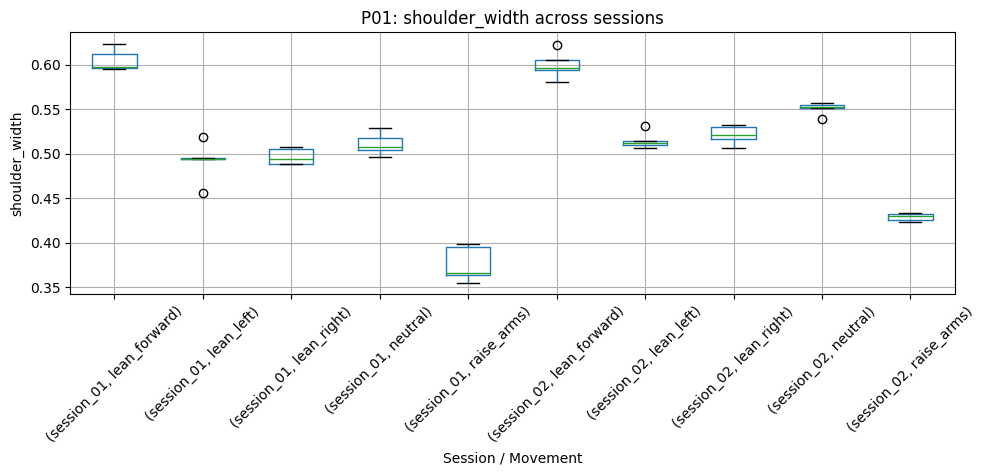

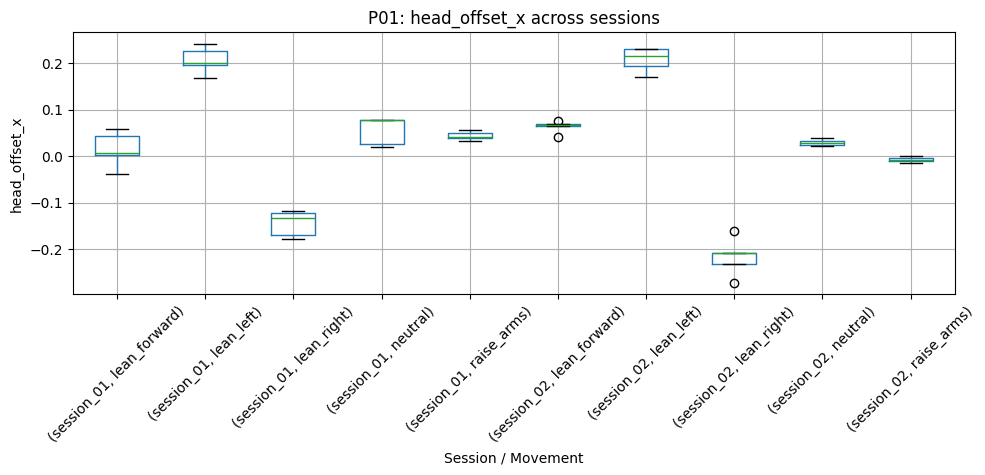

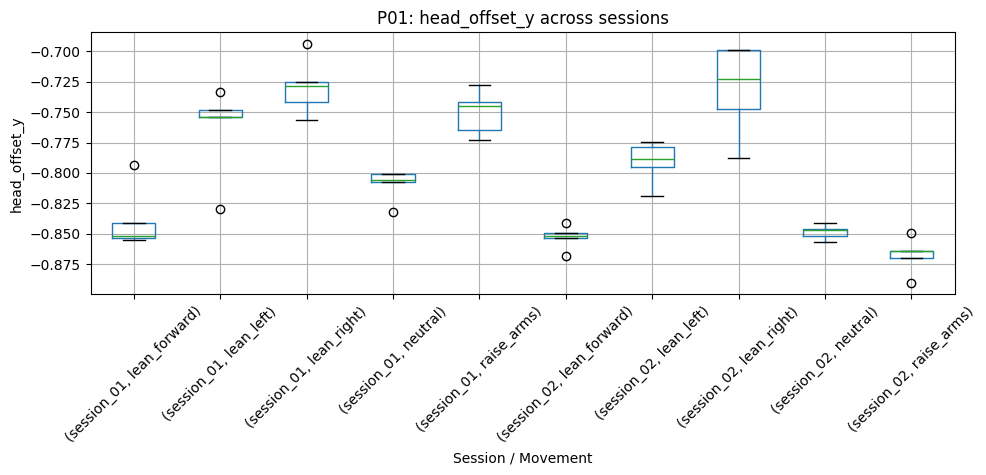

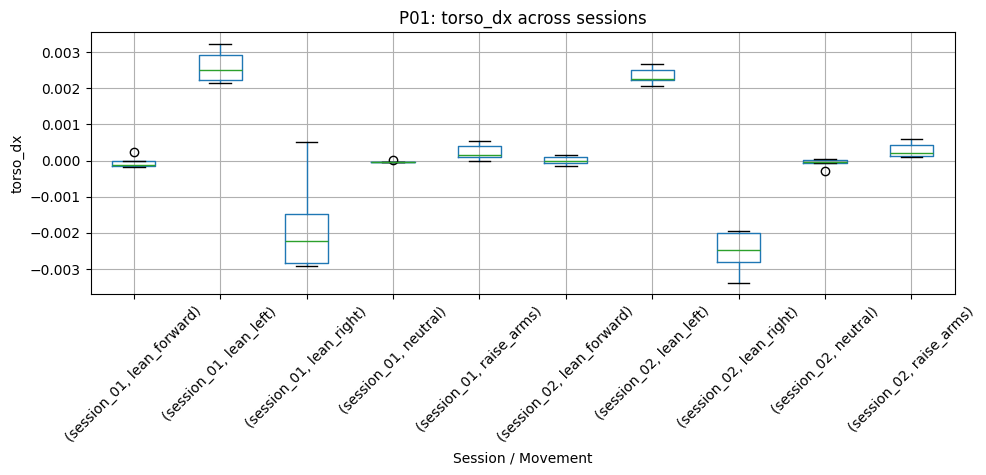

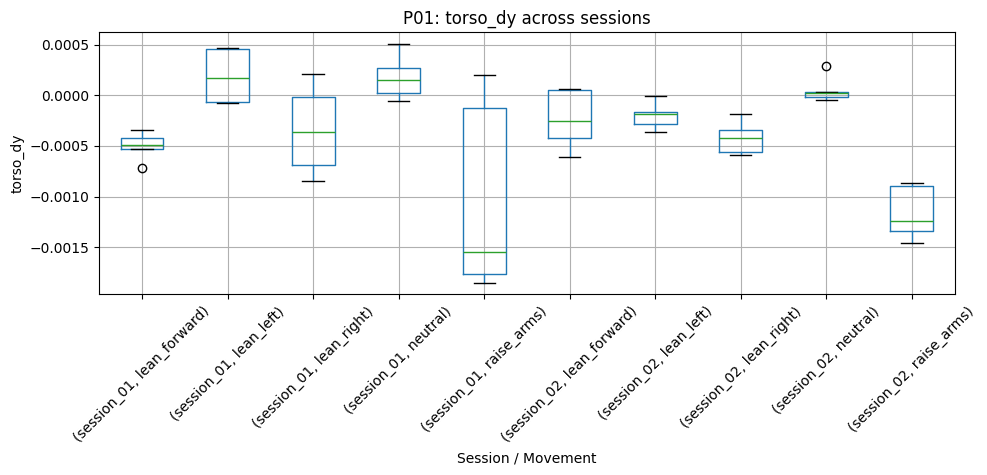

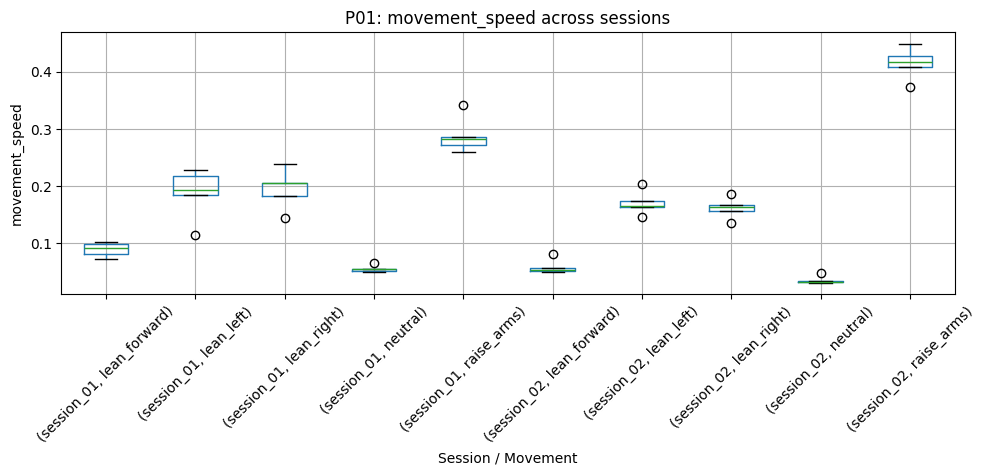

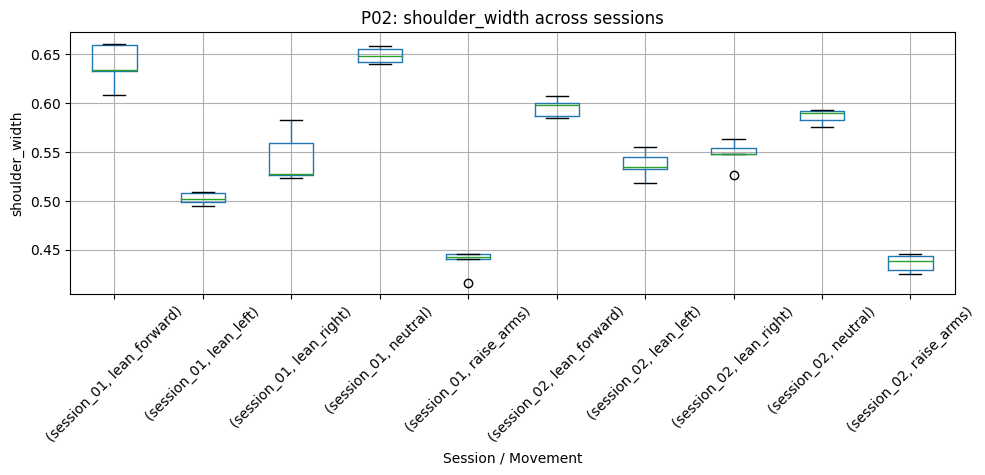

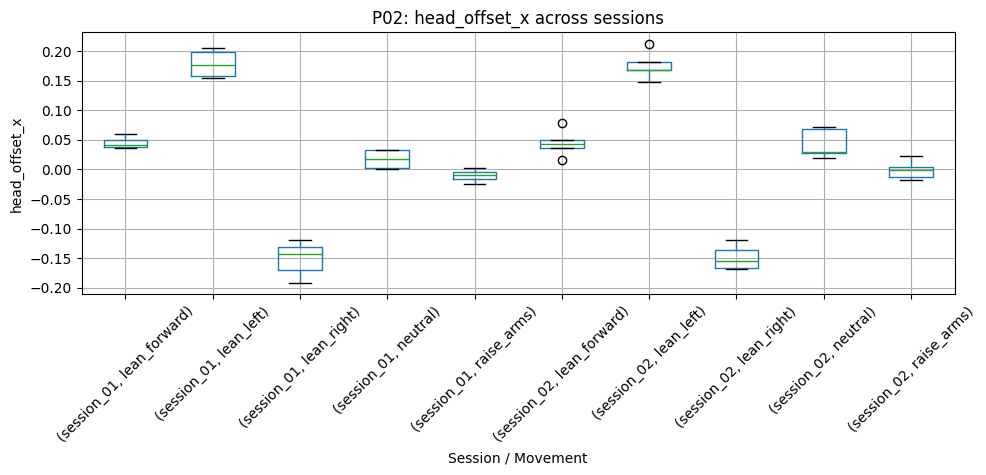

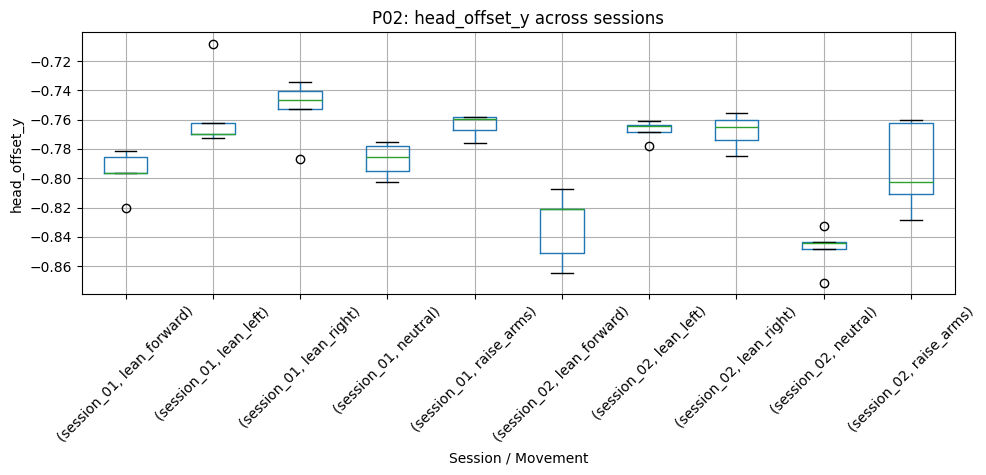

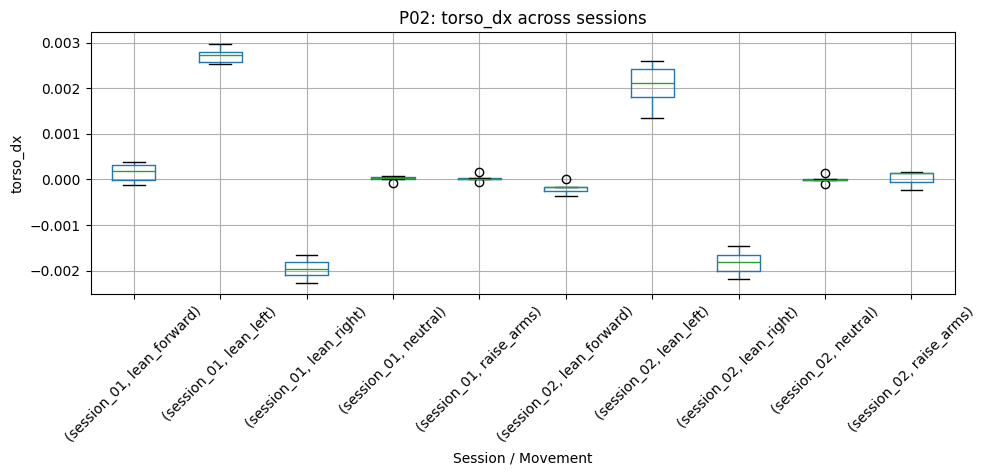

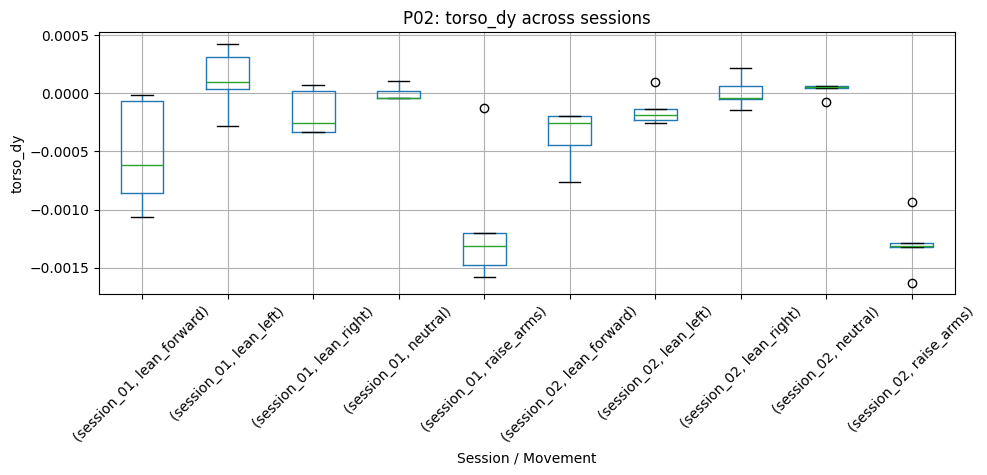

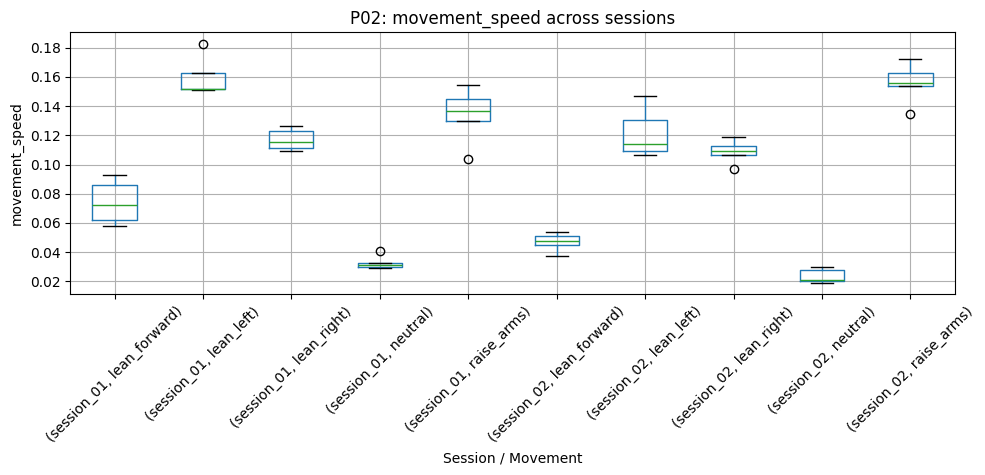

In [23]:
for participant in sorted(
    trial_features["participant_id"].unique()
):
    subset = trial_features[
        trial_features["participant_id"] == participant
    ]

    for feature in features_2d:
        subset.boxplot(
            column=feature,
            by=["session_id", "movement_label"],
            figsize=(10, 5),
        )

        plt.title(
            f"{participant}: {feature} across sessions"
        )
        plt.suptitle("")
        plt.xlabel("Session / Movement")
        plt.ylabel(feature)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

In [24]:
depth_summary = (
    trial_features.groupby("movement_label")[features_3d]
    .mean()
)

depth_summary

,head_offset_z,torso_dz,movement_speed_3d
movement_label,,,
lean_forward,-1.912090,-0.003696,1.169165
lean_left,-1.785905,0.000145,1.604627
lean_right,-1.720302,-0.000103,1.287603
neutral,-1.865146,0.000104,0.879555
raise_arms,-1.966086,0.004455,3.213255


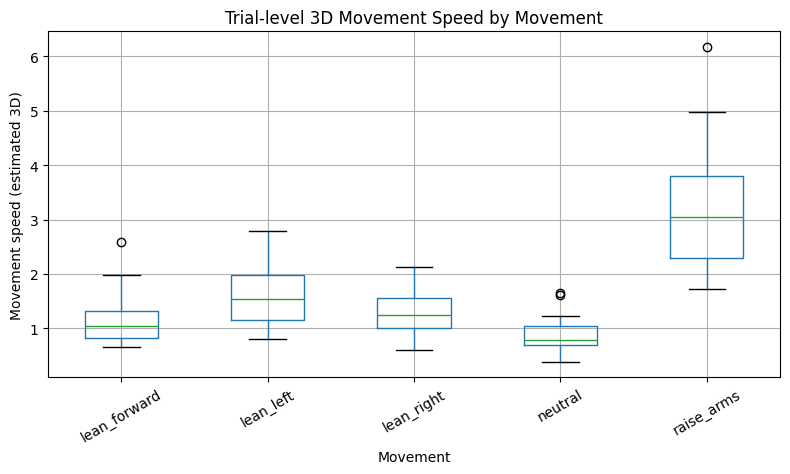

In [25]:
trial_features.boxplot(
    column="movement_speed_3d",
    by="movement_label",
    figsize=(8, 5),
)

plt.title("Trial-level 3D Movement Speed by Movement")
plt.suptitle("")
plt.xlabel("Movement")
plt.ylabel("Movement speed (estimated 3D)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [26]:
correlations = trial_features[
    features_2d + features_3d
].corr()

correlations.round(2)

,shoulder_width,head_offset_x,head_offset_y,torso_dx,torso_dy,movement_speed,head_offset_z,torso_dz,movement_speed_3d
shoulder_width,1.00,-0.00,-0.27,-0.11,0.47,-0.75,0.29,-0.56,-0.77
head_offset_x,-0.00,1.00,-0.24,0.93,0.18,-0.03,-0.23,-0.03,0.04
head_offset_y,-0.27,-0.24,1.00,-0.15,0.01,0.17,0.64,0.20,0.04
torso_dx,-0.11,0.93,-0.15,1.00,0.14,0.12,-0.17,0.01,0.13
torso_dy,0.47,0.18,0.01,0.14,1.00,-0.47,0.36,-0.42,-0.58
movement_speed,-0.75,-0.03,0.17,0.12,-0.47,1.00,-0.23,0.32,0.79
head_offset_z,0.29,-0.23,0.64,-0.17,0.36,-0.23,1.00,0.02,-0.47
torso_dz,-0.56,-0.03,0.20,0.01,-0.42,0.32,0.02,1.00,0.38
movement_speed_3d,-0.77,0.04,0.04,0.13,-0.58,0.79,-0.47,0.38,1.00


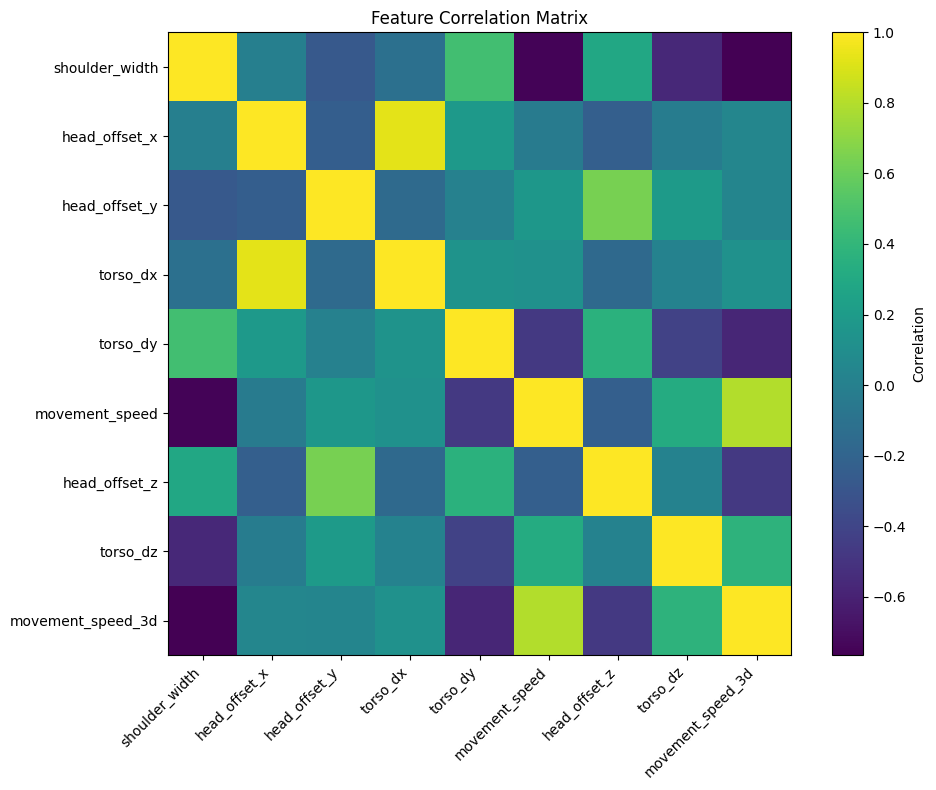

In [27]:
plt.figure(figsize=(10, 8))

plt.imshow(
    correlations,
    interpolation="nearest",
)

plt.xticks(
    range(len(correlations.columns)),
    correlations.columns,
    rotation=45,
    ha="right",
)

plt.yticks(
    range(len(correlations.columns)),
    correlations.columns,
)

plt.colorbar(label="Correlation")

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()